# Import

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [28]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis

In [29]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


## Load the DataFrames

In [30]:
with open("df_DY_event+btag.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

with open("df_H_event+btag.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_TT_event+btag.pkl", "rb") as f:
    df_TT_event = pickle.load(f)

In [31]:
df_TT_event["class"] = df_TT_event["label"]
df_TT_event.drop(columns=["label"], inplace=True)

In [42]:
df_DY_event["class"] = 0
df_H_event["class"] = 1
df_TT_event["class"] = 2

In [33]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt",
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

btag_cols = [
    "jet1_btagDeepFlavB", "jet2_btagDeepFlavB", "jet3_btagDeepFlavB",
    "jet1_btagPNetB", "jet2_btagPNetB", "jet3_btagPNetB",
    "jet1_btagRobustParTAK4B", "jet2_btagRobustParTAK4B", "jet3_btagRobustParTAK4B",
]

met_cols = [
    "MET_pt", "MET_phi", "MET_significance", "MET_sumEt"
]

train_cols = tau1_cols + tau2_cols + jet_cols + btag_cols + met_cols

y_cols = ["tau1_corr", "tau2_corr"]

## Balanced vs Unbalanced Datasets

In [43]:
df_all = (
    pd.concat([df_DY_event, df_H_event, df_TT_event], axis=0)
      .sample(frac=1.0, random_state=0)
      .reset_index(drop=True)
)

print(df_all["class"].value_counts(dropna=False))

class
2    138480
1     69370
0     18836
Name: count, dtype: int64


In [47]:
df_bal = (
    df_all
    .groupby("class", group_keys=False)
    .sample(n=N_bal, random_state=0)
    .sample(frac=1.0, random_state=0)
    .reset_index(drop=True)
)

print(df_bal["class"].value_counts())

class
2    18836
0    18836
1    18836
Name: count, dtype: int64


In [48]:
# split:
df_train_all, df_val_all, df_test_all = data.split_df_once(df_all, seed=0)
df_train_bal, df_val_bal, df_test_bal = data.split_df_once(df_bal, seed=0)

print("UNBALANCED")
print(df_train_all["class"].value_counts())
print(df_val_all["class"].value_counts())
print(df_test_all["class"].value_counts())

print("\nBALANCED")
print(df_train_bal["class"].value_counts())
print(df_val_bal["class"].value_counts())
print(df_test_bal["class"].value_counts())

UNBALANCED
class
2    110743
1     55535
0     15070
Name: count, dtype: int64
class
2    13923
1     6887
0     1859
Name: count, dtype: int64
class
2    13814
1     6948
0     1907
Name: count, dtype: int64

BALANCED
class
2    15127
1    15088
0    14991
Name: count, dtype: int64
class
0    1898
1    1891
2    1862
Name: count, dtype: int64
class
0    1947
1    1857
2    1847
Name: count, dtype: int64


In [49]:
# scaling:
OUTDIR = "../results/prepared_splits_DY_H_TT_btag"
os.makedirs(OUTDIR, exist_ok=True)

paths_unbalanced = data.apply_and_save_all_scalings(
    df_train_all, df_val_all, df_test_all,
    dataset_tag="unbalanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

paths_balanced = data.apply_and_save_all_scalings(
    df_train_bal, df_val_bal, df_test_bal,
    dataset_tag="balanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

[unbalanced] saved X_NONE__Y_NONE -> ../results/prepared_splits_DY_H_TT_btag/unbalanced/X_NONE__Y_NONE
[unbalanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits_DY_H_TT_btag/unbalanced/X_GLOBAL__Y_LOCAL
[unbalanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits_DY_H_TT_btag/unbalanced/X_GLOBAL__Y_GLOBAL
[unbalanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits_DY_H_TT_btag/unbalanced/X_LOCAL__Y_LOCAL
[unbalanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits_DY_H_TT_btag/unbalanced/X_NONE__Y_LOCAL
[balanced] saved X_NONE__Y_NONE -> ../results/prepared_splits_DY_H_TT_btag/balanced/X_NONE__Y_NONE
[balanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits_DY_H_TT_btag/balanced/X_GLOBAL__Y_LOCAL
[balanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits_DY_H_TT_btag/balanced/X_GLOBAL__Y_GLOBAL
[balanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits_DY_H_TT_btag/balanced/X_LOCAL__Y_LOCAL
[balanced] saved X_NONE__Y_LOCAL -> ../results/prep

In [50]:
# scelgo i 3 modes principali:
MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
]

## Training

In [ ]:
OUT_ROOT = "../results/runs_DY_H_TT_btag"

DATASETS = {
    "unbalanced": paths_unbalanced,
    "balanced": paths_balanced,
}

tag = "HUBER_pat100_ep5000_seed0_hidden256x5_btag_TTbar"

all_results = {}

for dataset_tag, paths in DATASETS.items():

    results_cfg = {}

    for mode in MODES:

        set_seed()

        print("\n" + "="*80)
        print(f"TRAIN {dataset_tag.upper()} — {mode}")
        print("="*80)

        res = training.train_one_mode(
            mode_dir=paths[mode],
            train_cols=train_cols,
            y_cols=y_cols,
            loss_type="huber",
            patience=100,
            epochs=5000,
            hidden=(256, 256, 256, 256, 256),
        )

        results_cfg[mode] = res

        save_dir = os.path.join(
            OUT_ROOT,
            dataset_tag,
            tag,
            mode,
        )

        training.save_run(res, save_dir)

        print("saved ->", save_dir)

    all_results[dataset_tag] = results_cfg


TRAIN UNBALANCED — X_NONE__Y_NONE
[ep    1] train=0.499673  val=0.458690  best=0.458690  bad=0/100
[ep   10] train=0.444993  val=0.444271  best=0.444271  bad=0/100
[ep   20] train=0.410699  val=0.477640  best=0.402181  bad=2/100
[ep   30] train=0.330767  val=0.350843  best=0.306588  bad=1/100
[ep   40] train=0.265466  val=0.247872  best=0.234605  bad=1/100
[ep   50] train=0.230535  val=0.212043  best=0.212043  bad=0/100
[ep   60] train=0.219956  val=0.206476  best=0.206476  bad=0/100


In [10]:
def load_prepared(mode_dir: str):
    df_tr = pd.read_pickle(os.path.join(mode_dir, "train.pkl"))
    df_va = pd.read_pickle(os.path.join(mode_dir, "val.pkl"))
    df_te = pd.read_pickle(os.path.join(mode_dir, "test.pkl"))
    scalers = joblib.load(os.path.join(mode_dir, "scalers.joblib"))
    return df_tr, df_va, df_te, scalers

In [14]:
OUT_ROOT = "../results/runs_prepare/deep_taupt30_ge2jets_pt20"

In [15]:
MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
]

DATASETS = {
    "unbalanced": paths_unbalanced,
    "balanced": paths_balanced,
}

OUT_ROOT = "../results/runs_prepare/deep_taupt30_ge2jets_pt20"

all_results_jets_huber_pat100 = {}

tag = "HUBER_pat100_ep5000_seed0_hidden256x5"

for dataset_tag, paths in DATASETS.items():

    results_cfg = {}

    for mode in MODES:

        set_seed()

        print("\n" + "="*80)
        print(f"TRAIN {dataset_tag.upper()} — {mode} — HUBER pat100 — DEEP + JETS")
        print("="*80)

        res = training.train_one_mode(
            mode_dir=paths[mode],
            train_cols=train_cols,
            y_cols=y_cols,
            loss_type="huber",
            patience=100,
            epochs=5000,
            hidden=(256, 256, 256, 256, 256),
        )

        results_cfg[mode] = res

        save_dir = os.path.join(
            OUT_ROOT,
            dataset_tag,
            tag,
            mode,
        )

        training.save_run(res, save_dir)

        print("saved ->", save_dir)

    all_results_jets_huber_pat100[dataset_tag] = results_cfg


TRAIN UNBALANCED — X_NONE__Y_NONE — HUBER pat100 — DEEP + JETS
[ep    1] train=0.552310  val=0.489464  best=0.489464  bad=0/100
[ep   10] train=0.473543  val=0.478111  best=0.469949  bad=1/100
[ep   20] train=0.466105  val=0.468096  best=0.460403  bad=9/100
[ep   30] train=0.456410  val=0.447144  best=0.447144  bad=0/100
[ep   40] train=0.436454  val=0.462664  best=0.432999  bad=4/100
[ep   50] train=0.392436  val=0.378827  best=0.378827  bad=0/100
[ep   60] train=0.386392  val=0.345793  best=0.345793  bad=0/100
[ep   70] train=0.351791  val=0.343299  best=0.330840  bad=6/100
[ep   80] train=0.324547  val=0.310619  best=0.300622  bad=1/100
[ep   90] train=0.314490  val=0.324261  best=0.294717  bad=4/100
[ep  100] train=0.309879  val=0.310355  best=0.294717  bad=14/100
[ep  110] train=0.318642  val=0.301746  best=0.288593  bad=4/100
[ep  120] train=0.301323  val=0.329729  best=0.273397  bad=2/100
[ep  130] train=0.284935  val=0.290845  best=0.273397  bad=12/100
[ep  140] train=0.297741

# Predictions

In [16]:
# Carico le run (JET SELECTION)
results_unbalanced_huber_pat100_ep5000_deep_jets = {}

for mode in MODES:

    run_dir = os.path.join(
        OUT_ROOT,
        "unbalanced",
        "HUBER_pat100_ep5000_seed0_hidden256x5",
        mode,
    )

    results_unbalanced_huber_pat100_ep5000_deep_jets[mode] = training.load_run(run_dir)

    print("loaded ->", run_dir)

results_balanced_huber_pat100_ep5000_deep_jets = {}

for mode in MODES:

    run_dir = os.path.join(
        OUT_ROOT,
        "balanced",
        "HUBER_pat100_ep5000_seed0_hidden256x5",
        mode,
    )

    results_balanced_huber_pat100_ep5000_deep_jets[mode] = training.load_run(run_dir)

    print("loaded ->", run_dir)

loaded -> ../results/runs_prepare/deep_taupt30_ge2jets_pt20/unbalanced/HUBER_pat100_ep5000_seed0_hidden256x5/X_NONE__Y_NONE
loaded -> ../results/runs_prepare/deep_taupt30_ge2jets_pt20/unbalanced/HUBER_pat100_ep5000_seed0_hidden256x5/X_GLOBAL__Y_GLOBAL
loaded -> ../results/runs_prepare/deep_taupt30_ge2jets_pt20/unbalanced/HUBER_pat100_ep5000_seed0_hidden256x5/X_LOCAL__Y_LOCAL
loaded -> ../results/runs_prepare/deep_taupt30_ge2jets_pt20/balanced/HUBER_pat100_ep5000_seed0_hidden256x5/X_NONE__Y_NONE
loaded -> ../results/runs_prepare/deep_taupt30_ge2jets_pt20/balanced/HUBER_pat100_ep5000_seed0_hidden256x5/X_GLOBAL__Y_GLOBAL
loaded -> ../results/runs_prepare/deep_taupt30_ge2jets_pt20/balanced/HUBER_pat100_ep5000_seed0_hidden256x5/X_LOCAL__Y_LOCAL


In [20]:
TEST_DFS_JETS = {
    "unbalanced": df_test_all,
    "balanced": df_test_bal,
}

RESULTS_JETS = {
    "unbalanced": results_unbalanced_huber_pat100_ep5000_deep_jets,
    "balanced": results_balanced_huber_pat100_ep5000_deep_jets,
}

all_preds_jets_huber_pat100 = {}

for dataset_tag in ["unbalanced", "balanced"]:

    preds_cfg = {}
    df_test_ref = TEST_DFS_JETS[dataset_tag]
    results_cfg = RESULTS_JETS[dataset_tag]

    for mode in MODES:
        res = results_cfg[mode]

        df_pred = model.predict_tau_corr_auto(
            df=df_test_ref,
            res=res,
            train_cols=train_cols,
            y_cols=y_cols,
        )

        preds_cfg[mode] = df_pred
        print(f"{dataset_tag} | {mode} prediction done")

    all_preds_jets_huber_pat100[dataset_tag] = preds_cfg

unbalanced | X_NONE__Y_NONE prediction done
unbalanced | X_GLOBAL__Y_GLOBAL prediction done
unbalanced | X_LOCAL__Y_LOCAL prediction done
balanced | X_NONE__Y_NONE prediction done
balanced | X_GLOBAL__Y_GLOBAL prediction done
balanced | X_LOCAL__Y_LOCAL prediction done


## Masses

In [22]:
masses_unbalanced_huber_pat100_ep5000_deep_jets = {}

for mode in MODES:

    dfp = all_preds_jets_huber_pat100["unbalanced"][mode]

    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbalanced_huber_pat100_ep5000_deep_jets[mode] = m

    print(
        mode,
        "UNBALANCED HUBER pat100 ep5000 deep + jets done:",
        float(np.mean(m)),
        float(np.std(m)),
    )


masses_balanced_huber_pat100_ep5000_deep_jets = {}

for mode in MODES:

    dfp = all_preds_jets_huber_pat100["balanced"][mode]

    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_balanced_huber_pat100_ep5000_deep_jets[mode] = m

    print(
        mode,
        "BALANCED HUBER pat100 ep5000 deep + jets done:",
        float(np.mean(m)),
        float(np.std(m)),
    )

X_NONE__Y_NONE UNBALANCED HUBER pat100 ep5000 deep + jets done: 119.22391132771081 21.13176305709363
X_GLOBAL__Y_GLOBAL UNBALANCED HUBER pat100 ep5000 deep + jets done: 119.65893402958214 18.362109658904185
X_LOCAL__Y_LOCAL UNBALANCED HUBER pat100 ep5000 deep + jets done: 118.81014739064133 14.981894704285963
X_NONE__Y_NONE BALANCED HUBER pat100 ep5000 deep + jets done: 108.07529805441213 34.072818917853986
X_GLOBAL__Y_GLOBAL BALANCED HUBER pat100 ep5000 deep + jets done: 108.99747150552483 27.001175155172458
X_LOCAL__Y_LOCAL BALANCED HUBER pat100 ep5000 deep + jets done: 109.13636695989936 26.38378535242224


In [23]:
# salvo le masse (JET SELECTION)
OUT_MASSES = "../results/masses"

np.savez_compressed(
    os.path.join(OUT_MASSES, "masses_unbalanced_huber_pat100_ep5000_deep_jets.npz"),
    **masses_unbalanced_huber_pat100_ep5000_deep_jets
)

print("saved -> masses_unbalanced_huber_pat100_ep5000_deep_jets.npz")

np.savez_compressed(
    os.path.join(OUT_MASSES, "masses_balanced_huber_pat100_ep5000_deep_jets.npz"),
    **masses_balanced_huber_pat100_ep5000_deep_jets
)

print("saved -> masses_balanced_huber_pat100_ep5000_deep_jets.npz")

saved -> masses_unbalanced_huber_pat100_ep5000_deep_jets.npz
saved -> masses_balanced_huber_pat100_ep5000_deep_jets.npz


In [24]:
mask_dy = df_test_all["class"].to_numpy() == 0
mask_h  = df_test_all["class"].to_numpy() == 1

masses_unbalanced_huber_pat100_ep5000_deep_jets_dy = {
    mode: m[mask_dy]
    for mode, m in masses_unbalanced_huber_pat100_ep5000_deep_jets.items()
}

masses_unbalanced_huber_pat100_ep5000_deep_jets_h = {
    mode: m[mask_h]
    for mode, m in masses_unbalanced_huber_pat100_ep5000_deep_jets.items()
}

np.savez_compressed(
    os.path.join(OUT_MASSES, "masses_unbalanced_huber_pat100_ep5000_deep_jets_dy.npz"),
    **masses_unbalanced_huber_pat100_ep5000_deep_jets_dy
)

np.savez_compressed(
    os.path.join(OUT_MASSES, "masses_unbalanced_huber_pat100_ep5000_deep_jets_h.npz"),
    **masses_unbalanced_huber_pat100_ep5000_deep_jets_h
)

print("saved deep + jets DY/H files")

mask_dy = df_test_bal["class"].to_numpy() == 0
mask_h  = df_test_bal["class"].to_numpy() == 1

masses_balanced_huber_pat100_ep5000_deep_jets_dy = {
    mode: m[mask_dy]
    for mode, m in masses_balanced_huber_pat100_ep5000_deep_jets.items()
}

masses_balanced_huber_pat100_ep5000_deep_jets_h = {
    mode: m[mask_h]
    for mode, m in masses_balanced_huber_pat100_ep5000_deep_jets.items()
}

np.savez_compressed(
    os.path.join(OUT_MASSES, "masses_balanced_huber_pat100_ep5000_deep_jets_dy.npz"),
    **masses_balanced_huber_pat100_ep5000_deep_jets_dy
)

np.savez_compressed(
    os.path.join(OUT_MASSES, "masses_balanced_huber_pat100_ep5000_deep_jets_h.npz"),
    **masses_balanced_huber_pat100_ep5000_deep_jets_h
)

print("saved balanced deep + jets DY/H files")

saved deep + jets DY/H files
saved balanced deep + jets DY/H files


# Comparison Deep NN without and with Jets Selection

In [26]:
# carico la baseline (solo unbalanced)
baseline_masses_split = {}

for proc in ["dy", "h"]:

    fname = f"masses_unbalanced_huber_pat100_ep5000_deep_{proc}.npz"
    path = os.path.join(OUT_MASSES, fname)

    data = np.load(path)
    baseline_masses_split[("unbalanced", proc)] = {k: data[k] for k in data.files}

    print("loaded baseline ->", fname)

loaded baseline -> masses_unbalanced_huber_pat100_ep5000_deep_dy.npz
loaded baseline -> masses_unbalanced_huber_pat100_ep5000_deep_h.npz


In [139]:
jets_masses_split = {
    ("unbalanced", "dy"): masses_unbalanced_huber_pat100_ep5000_deep_jets_dy,
    ("unbalanced", "h"):  masses_unbalanced_huber_pat100_ep5000_deep_jets_h,
    ("balanced", "dy"):   masses_balanced_huber_pat100_ep5000_deep_jets_dy,
    ("balanced", "h"):    masses_balanced_huber_pat100_ep5000_deep_jets_h,
}

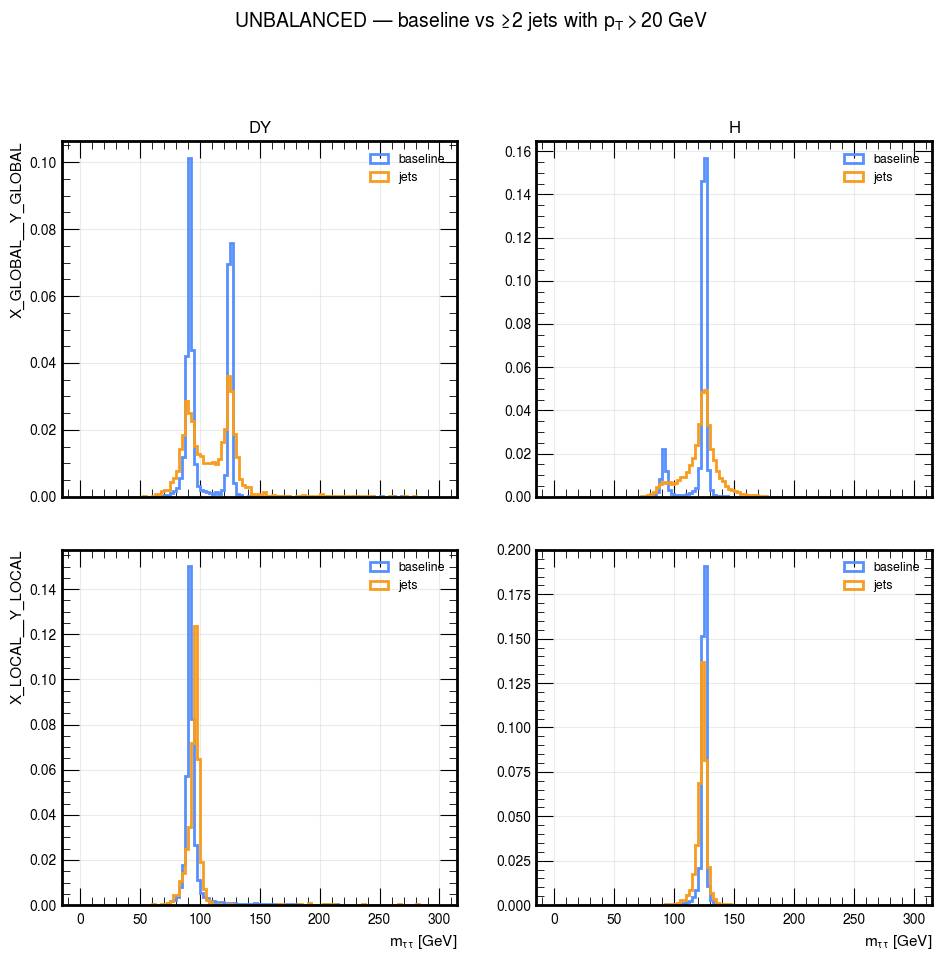

KeyError: ('balanced', 'dy')

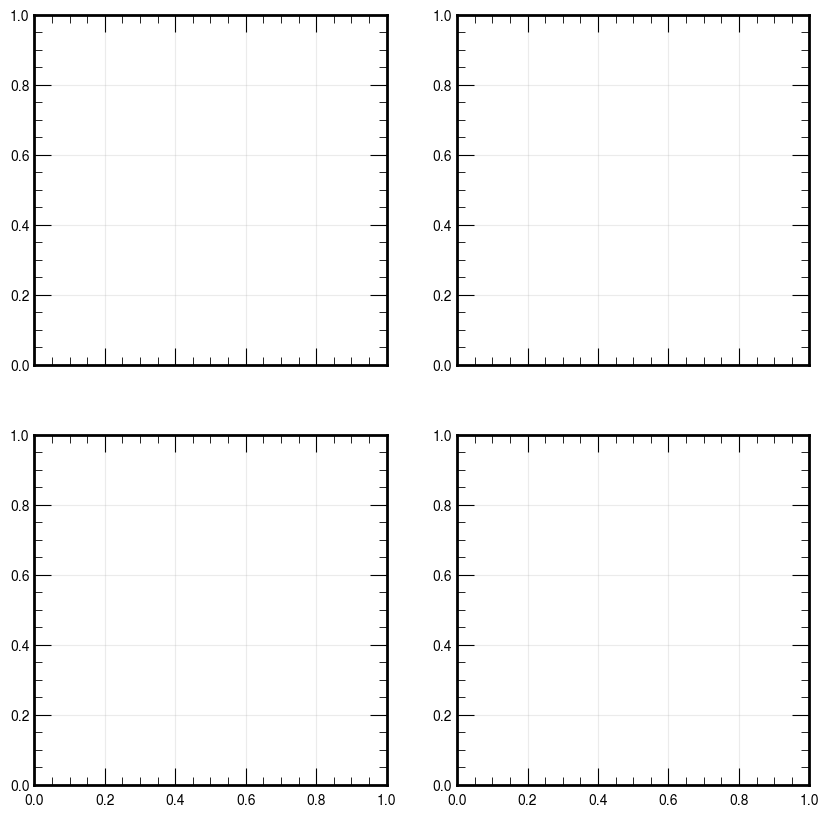

In [140]:
MODES = [
   # "X_NONE__Y_NONE",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
]

PROCS = ["dy", "h"]

for dataset_tag in [ "unbalanced"]:

    fig, axes = plt.subplots(
        nrows=len(MODES),
        ncols=len(PROCS),
        figsize=(10, 10),
        sharex=True,
        sharey=False,
    )

    for i, mode in enumerate(MODES):
        for j, proc in enumerate(PROCS):

            ax = axes[i, j]

            m_base = baseline_masses_split[(dataset_tag, proc)][mode]
            m_jets = jets_masses_split[(dataset_tag, proc)][mode]

            ax.hist(
                m_base,
                bins=120,
                range=(0, 300),
                density=True,
                histtype="step",
                linewidth=2,
                label="baseline",
            )

            ax.hist(
                m_jets,
                bins=120,
                range=(0, 300),
                density=True,
                histtype="step",
                linewidth=2,
                label="jets",
            )

            if i == 0:
                ax.set_title(proc.upper())

            if j == 0:
                ax.set_ylabel(mode)

            if i == len(MODES) - 1:
                ax.set_xlabel(r"$m_{\tau\tau}$ [GeV]")

            ax.legend(fontsize=9)

    fig.suptitle(
        f"{dataset_tag.upper()} — baseline vs ≥2 jets with $p_T > 20$ GeV",
        fontsize=14,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

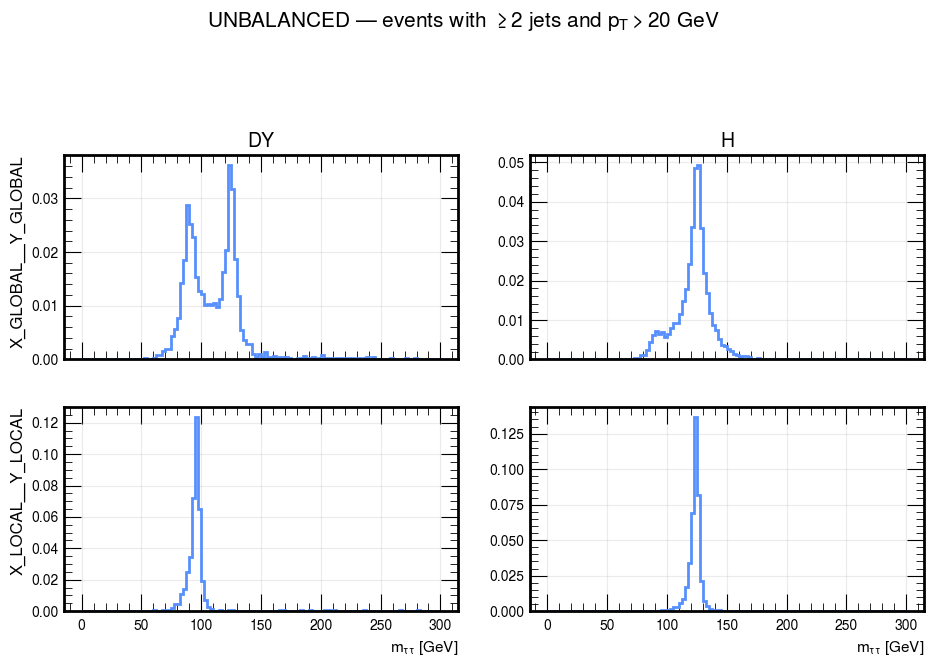

In [108]:
MODES = [
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
]

PROCS = ["dy", "h"]

for dataset_tag in ["unbalanced"]:

    fig, axes = plt.subplots(
        nrows=len(MODES),
        ncols=len(PROCS),
        figsize=(10, 7),
        sharex=True,
        sharey=False,
    )

    for i, mode in enumerate(MODES):
        for j, proc in enumerate(PROCS):

            ax = axes[i, j]

            m_jets = jets_masses_split[(dataset_tag, proc)][mode]

            ax.hist(
                m_jets,
                bins=120,
                range=(0, 300),
                density=True,
                histtype="step",
                linewidth=2,
            )

            if i == 0:
                ax.set_title(proc.upper(), fontsize=14)

            if j == 0:
                ax.set_ylabel(mode, fontsize=12)

            if i == len(MODES) - 1:
                ax.set_xlabel(r"$m_{\tau\tau}$ [GeV]")

    fig.suptitle(
        rf"{dataset_tag.upper()} — events with $\geq 2$ jets and $p_T > 20$ GeV",
        fontsize=15,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    plt.show()

## Analysis
---

In [34]:
results_SB_baseline_vs_jets = []

dataset_tag = "unbalanced"

for mode in MODES:

    # -------------------
    # BASELINE
    # -------------------
    h_base  = baseline_masses_split[(dataset_tag, "h")][mode]
    dy_base = baseline_masses_split[(dataset_tag, "dy")][mode]

    mu_base, sigma_base, low_base, high_base = analysis.fit_signal_window(h_base)
    S_base, B_base, SB_base, SsqrtB_base = analysis.compute_SB(
        h_base, dy_base, (low_base, high_base)
    )

    results_SB_baseline_vs_jets.append({
        "mode": mode,
        "selection": "baseline",
        "mu": mu_base,
        "sigma": sigma_base,
        "low": low_base,
        "high": high_base,
        "S": S_base,
        "B": B_base,
        "S/B": SB_base,
        "S/sqrtB": SsqrtB_base,
    })

    # -------------------
    # JETS
    # -------------------
    h_jets  = jets_masses_split[(dataset_tag, "h")][mode]
    dy_jets = jets_masses_split[(dataset_tag, "dy")][mode]

    mu_jets, sigma_jets, low_jets, high_jets = analysis.fit_signal_window(h_jets)
    S_jets, B_jets, SB_jets, SsqrtB_jets = analysis.compute_SB(
        h_jets, dy_jets, (low_jets, high_jets)
    )

    results_SB_baseline_vs_jets.append({
        "mode": mode,
        "selection": "jets",
        "mu": mu_jets,
        "sigma": sigma_jets,
        "low": low_jets,
        "high": high_jets,
        "S": S_jets,
        "B": B_jets,
        "S/B": SB_jets,
        "S/sqrtB": SsqrtB_jets,
    })

    print(
        mode,
        f"BASELINE: mu={mu_base:.2f}, sigma={sigma_base:.2f}, S/B={SB_base:.3f}",
        f" | JETS: mu={mu_jets:.2f}, sigma={sigma_jets:.2f}, S/B={SB_jets:.3f}",
    )

X_GLOBAL__Y_GLOBAL BASELINE: mu=120.62, sigma=11.99, S/B=6.192  | JETS: mu=121.59, sigma=15.62, S/B=6.187
X_LOCAL__Y_LOCAL BASELINE: mu=124.59, sigma=3.90, S/B=222.045  | JETS: mu=123.04, sigma=6.74, S/B=950.600


In [35]:
df_SB_baseline_vs_jets = pd.DataFrame(results_SB_baseline_vs_jets)
df_SB_baseline_vs_jets

,mode,selection,mu,sigma,low,high,S,B,S/B,S/sqrtB
0,X_GLOBAL__Y_GLOBAL,baseline,120.623802,11.994131,96.635540,144.612063,22333,3607,6.191572,371.855316
1,X_GLOBAL__Y_GLOBAL,jets,121.593928,15.616510,90.360908,152.826947,9200,1487,6.186954,238.579071
2,X_LOCAL__Y_LOCAL,baseline,124.592832,3.899475,116.793881,132.391783,24647,111,222.045045,2339.389712
3,X_LOCAL__Y_LOCAL,jets,123.037713,6.741823,109.554067,136.521359,9506,10,950.600000,3006.061144


In [118]:
df_SB = pd.DataFrame(results_SB_baseline_vs_jets)

df_SB_jets = (
    df_SB
    .query("selection == 'jets'")
    .loc[:, ["mode", "mu", "sigma", "low", "high", "S", "B", "S/B", "S/sqrtB"]]
    .copy()
)

df_SB_jets["mode"] = df_SB_jets["mode"].replace({
    "X_GLOBAL__Y_GLOBAL": "Global → Global",
    "X_LOCAL__Y_LOCAL": "Local → Local",
})

df_SB_jets = df_SB_jets.round({
    "mu": 2,
    "sigma": 2,
    "low": 2,
    "high": 2,
    "S": 0,
    "B": 0,
    "S/B": 3,
    "S/sqrtB": 2,
})

df_SB_slide = (
    df_SB_jets
    .loc[:, ["mode", "mu", "sigma", "S/B", "S/sqrtB"]]
    .rename(columns={
        "mode": "Scaling strategy",
        "mu": r"$\mu_H$ [GeV]",
        "sigma": r"$\sigma_H$ [GeV]",
        "S/B": "S/B",
        "S/sqrtB": r"$S/\sqrt{B}$",
    })
)

df_SB_slide

,Scaling strategy,$\mu_H$ [GeV],$\sigma_H$ [GeV],S/B,$S/\sqrt{B}$
1,Global → Global,121.59,15.62,6.187,238.58
3,Local → Local,123.04,6.74,950.600,3006.06


# Bad events Reconstruction

In [50]:
df_tr_g, df_va_g, df_te_global, scalers_g = training.load_prepared(
    paths_unbalanced["X_GLOBAL__Y_GLOBAL"]
)

df_tr_l, df_va_l, df_te_local, scalers_l = training.load_prepared(
    paths_unbalanced["X_LOCAL__Y_LOCAL"]
)

df_tr_g_bal, df_va_g_bal, df_te_global_bal, scalers_g_bal = training.load_prepared(
    paths_balanced["X_GLOBAL__Y_GLOBAL"]
)

df_tr_l_bal, df_va_l_bal, df_te_local_bal, scalers_l_bal = training.load_prepared(
    paths_balanced["X_LOCAL__Y_LOCAL"]
)

In [53]:
mode = "X_GLOBAL__Y_GLOBAL"

# =========================
# UNBALANCED
# =========================
m_pred_unbal = masses_unbalanced_huber_pat100_ep5000_deep_jets[mode]

mask_h_bad_unbal  = (df_test_all["class"].to_numpy() == 1) & (m_pred_unbal < 100)
mask_dy_bad_unbal = (df_test_all["class"].to_numpy() == 0) & (m_pred_unbal > 110)

df_h_bad_raw_unbal    = df_test_all[mask_h_bad_unbal].copy()
df_h_bad_global_unbal = df_te_global[mask_h_bad_unbal].copy()
df_h_bad_local_unbal  = df_te_local[mask_h_bad_unbal].copy()

df_dy_bad_raw_unbal    = df_test_all[mask_dy_bad_unbal].copy()
df_dy_bad_global_unbal = df_te_global[mask_dy_bad_unbal].copy()
df_dy_bad_local_unbal  = df_te_local[mask_dy_bad_unbal].copy()

print("UNBALANCED")
print("H bad :", len(df_h_bad_raw_unbal))
print("DY bad:", len(df_dy_bad_raw_unbal))


# =========================
# BALANCED
# =========================
m_pred_bal = masses_balanced_huber_pat100_ep5000_deep_jets[mode]

mask_h_bad_bal  = (df_test_bal["class"].to_numpy() == 1) & (m_pred_bal < 100)
mask_dy_bad_bal = (df_test_bal["class"].to_numpy() == 0) & (m_pred_bal > 110)

df_h_bad_raw_bal    = df_test_bal[mask_h_bad_bal].copy()
df_h_bad_global_bal = df_te_global_bal[mask_h_bad_bal].copy()
df_h_bad_local_bal  = df_te_local_bal[mask_h_bad_bal].copy()

df_dy_bad_raw_bal    = df_test_bal[mask_dy_bad_bal].copy()
df_dy_bad_global_bal = df_te_global_bal[mask_dy_bad_bal].copy()
df_dy_bad_local_bal  = df_te_local_bal[mask_dy_bad_bal].copy()

print("\nBALANCED")
print("H bad :", len(df_h_bad_raw_bal))
print("DY bad:", len(df_dy_bad_raw_bal))

UNBALANCED
H bad : 1052
DY bad: 974

BALANCED
H bad : 432
DY bad: 462


In [54]:
features_to_check = [
    "tau1_logpt", "tau2_logpt", "tau1_mass", "tau2_mass",
    "MET_logpt",
    "jet1_logpt", "jet2_logpt", "jet3_logpt",
    "jet1_eta", "jet2_eta", "jet3_eta",
    "jet1_phi", "jet2_phi", "jet3_phi",
    "jet1_mass", "jet2_mass", "jet3_mass",
]

In [55]:
def plot_scaling_comparison_grid(
    df_raw,
    df_global,
    df_local,
    features,
    bins=60,
    ncols=4,
    density=True,
    title="",
    use_robust_range=True,
    qlow=0.01,
    qhigh=0.99,
):
    n_features = len(features)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.2 * ncols, 3.2 * nrows),
        squeeze=False,
    )
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]

        x_raw = df_raw[feat].to_numpy()
        x_g   = df_global[feat].to_numpy()
        x_l   = df_local[feat].to_numpy()

        x_raw = x_raw[np.isfinite(x_raw)]
        x_g   = x_g[np.isfinite(x_g)]
        x_l   = x_l[np.isfinite(x_l)]

        if len(x_raw) == 0 or len(x_g) == 0 or len(x_l) == 0:
            ax.text(0.5, 0.5, f"{feat}\nno entries", ha="center", va="center")
            ax.set_axis_off()
            continue

        range_ = None
        if use_robust_range:
            x_all = np.concatenate([x_raw, x_g, x_l])
            lo = np.quantile(x_all, qlow)
            hi = np.quantile(x_all, qhigh)
            if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
                range_ = (lo, hi)

        ax.hist(
            x_raw,
            bins=bins,
            range=range_,
            density=density,
            histtype="step",
            linewidth=2,
            label="raw",
        )
        ax.hist(
            x_g,
            bins=bins,
            range=range_,
            density=density,
            histtype="step",
            linewidth=2,
            label="global",
        )
        ax.hist(
            x_l,
            bins=bins,
            range=range_,
            density=density,
            histtype="step",
            linewidth=2,
            label="local",
        )

        ax.set_title(feat, fontsize=10)
        ax.tick_params(labelsize=9)

        if i == 0:
            ax.legend(fontsize=9)

    for j in range(n_features, len(axes)):
        axes[j].set_axis_off()

    if title:
        fig.suptitle(title, fontsize=14)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

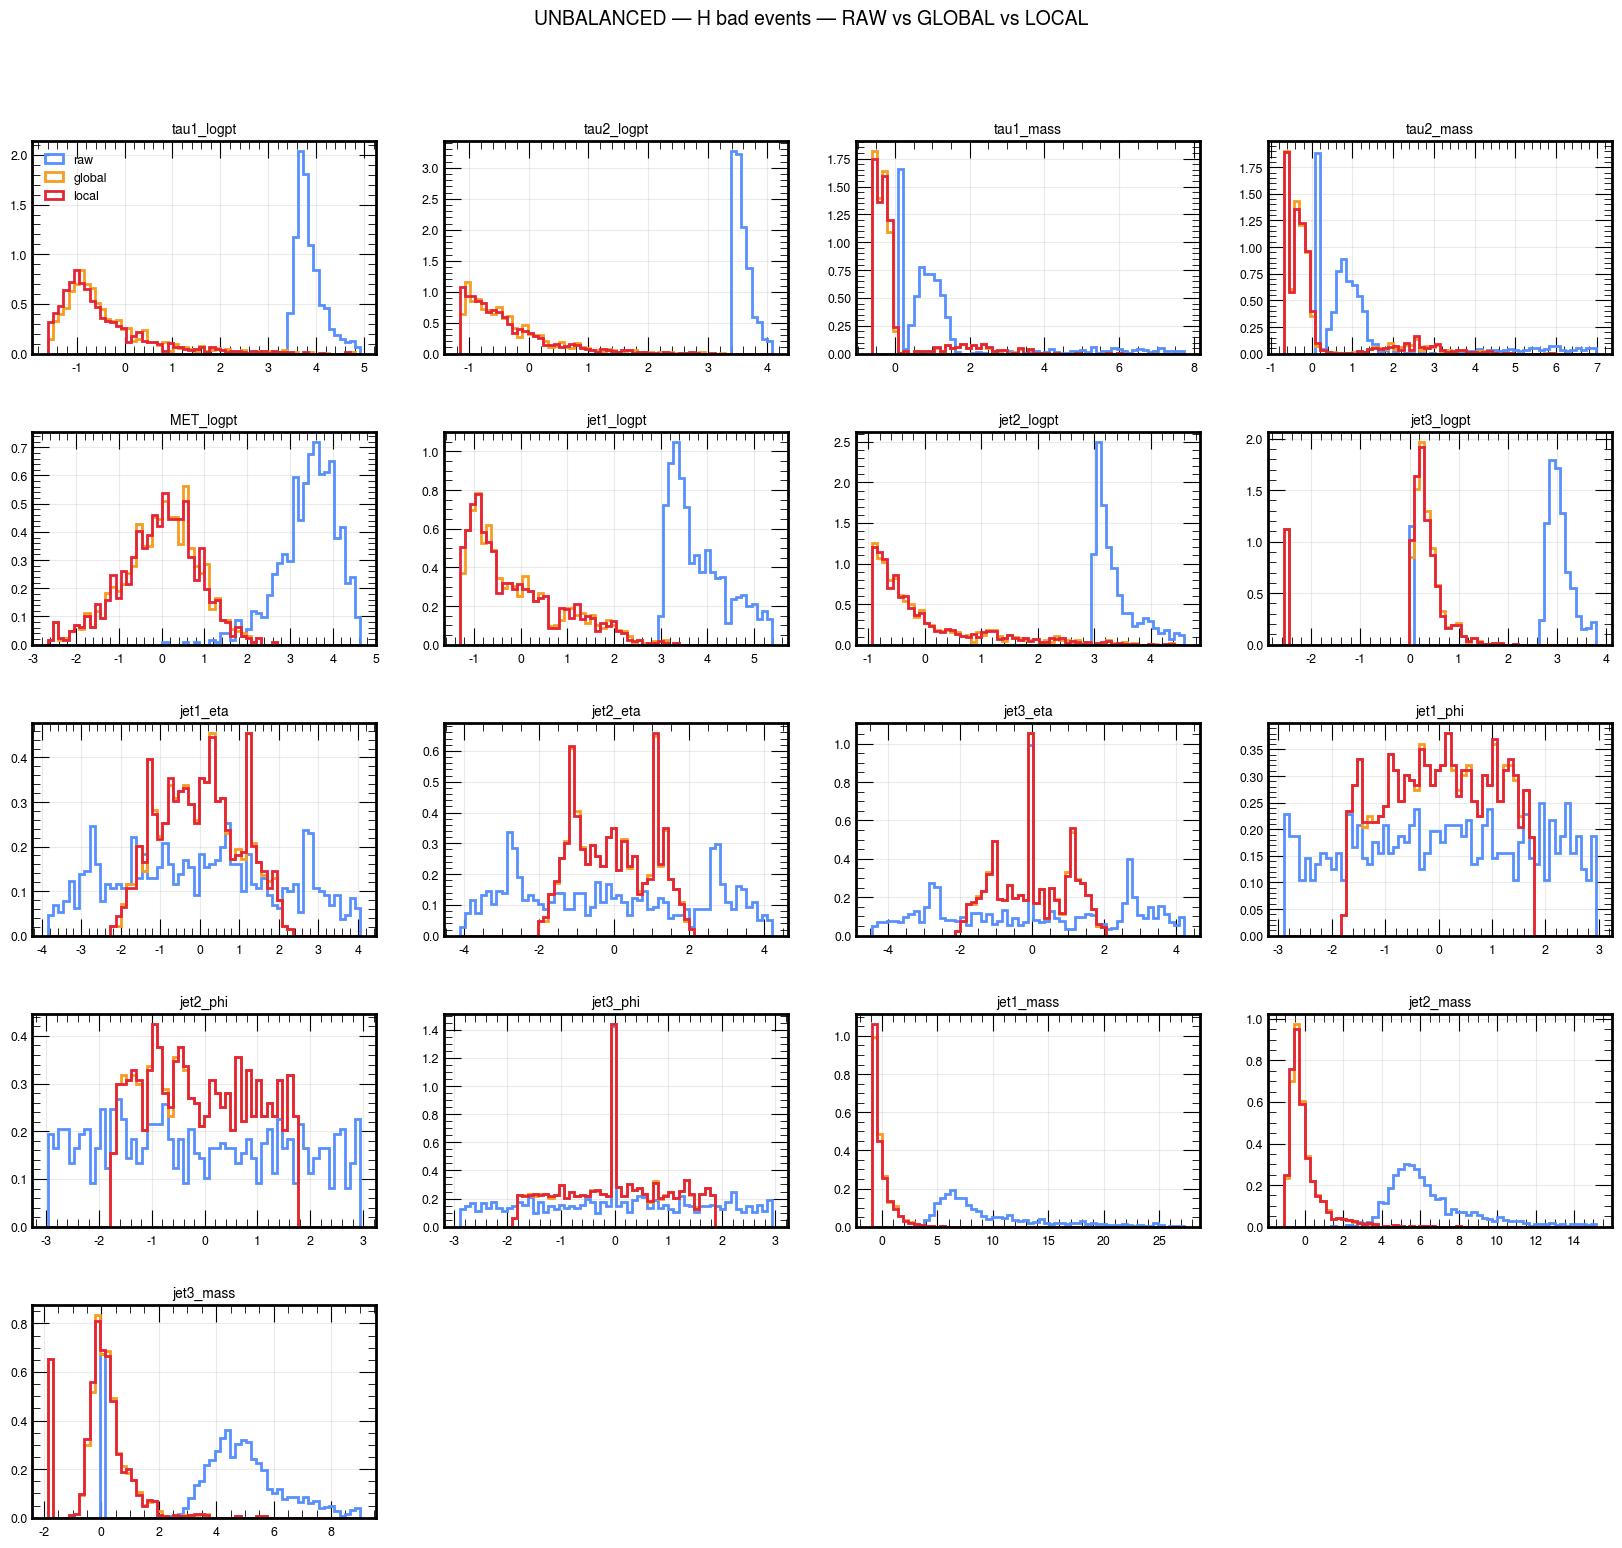

In [56]:
plot_scaling_comparison_grid(
    df_raw=df_h_bad_raw_unbal,
    df_global=df_h_bad_global_unbal,
    df_local=df_h_bad_local_unbal,
    features=features_to_check,
    bins=60,
    ncols=4,
    title="UNBALANCED — H bad events — RAW vs GLOBAL vs LOCAL",
)

In [59]:
def plot_bad_scaling_layout(
    df_h_raw,
    df_dy_raw,
    df_h_global,
    df_dy_global,
    df_h_local,
    df_dy_local,
    features,
    bins=60,
    density=True,
    figsize_per_row=3.2,
):

    n_features = len(features)

    fig, axes = plt.subplots(
        nrows=n_features,
        ncols=3,
        figsize=(12, figsize_per_row * n_features),
        squeeze=False,
    )

    for i, feat in enumerate(features):

        datasets = [
            (df_h_raw, df_dy_raw, "RAW"),
            (df_h_global, df_dy_global, "GLOBAL"),
            (df_h_local, df_dy_local, "LOCAL"),
        ]

        for j, (df_h, df_dy, title) in enumerate(datasets):

            ax = axes[i, j]

            x_h  = df_h[feat].to_numpy()
            x_dy = df_dy[feat].to_numpy()

            x_h  = x_h[np.isfinite(x_h)]
            x_dy = x_dy[np.isfinite(x_dy)]

            ax.hist(
                x_h,
                bins=bins,
                density=density,
                histtype="step",
                linewidth=2,
                label="H bad",
            )

            ax.hist(
                x_dy,
                bins=bins,
                density=density,
                histtype="step",
                linewidth=2,
                label="DY bad",
            )

            if i == 0:
                ax.set_title(title, fontsize=12)

            if j == 0:
                ax.set_ylabel(feat, fontsize=10)

            if i == 0 and j == 0:
                ax.legend(fontsize=9)

            ax.tick_params(labelsize=8)

    fig.tight_layout()
    plt.show()

In [102]:
features_to_check = ["tau1_mass"]

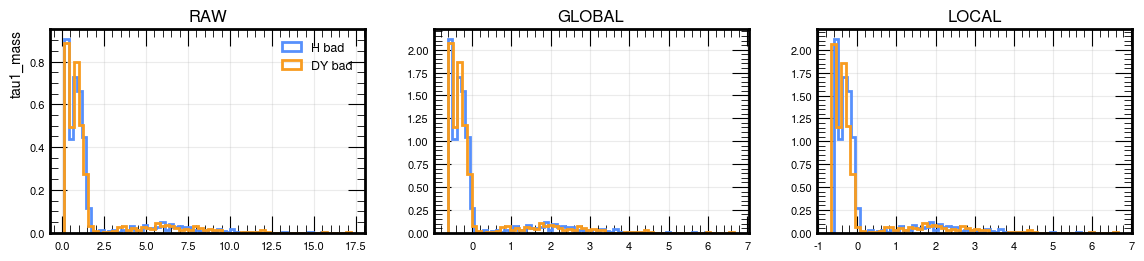

In [103]:
plot_bad_scaling_layout(
    df_h_raw=df_h_bad_raw_unbal,
    df_dy_raw=df_dy_bad_raw_unbal,
    df_h_global=df_h_bad_global_unbal,
    df_dy_global=df_dy_bad_global_unbal,
    df_h_local=df_h_bad_local_unbal,
    df_dy_local=df_dy_bad_local_unbal,
    features=features_to_check,
)

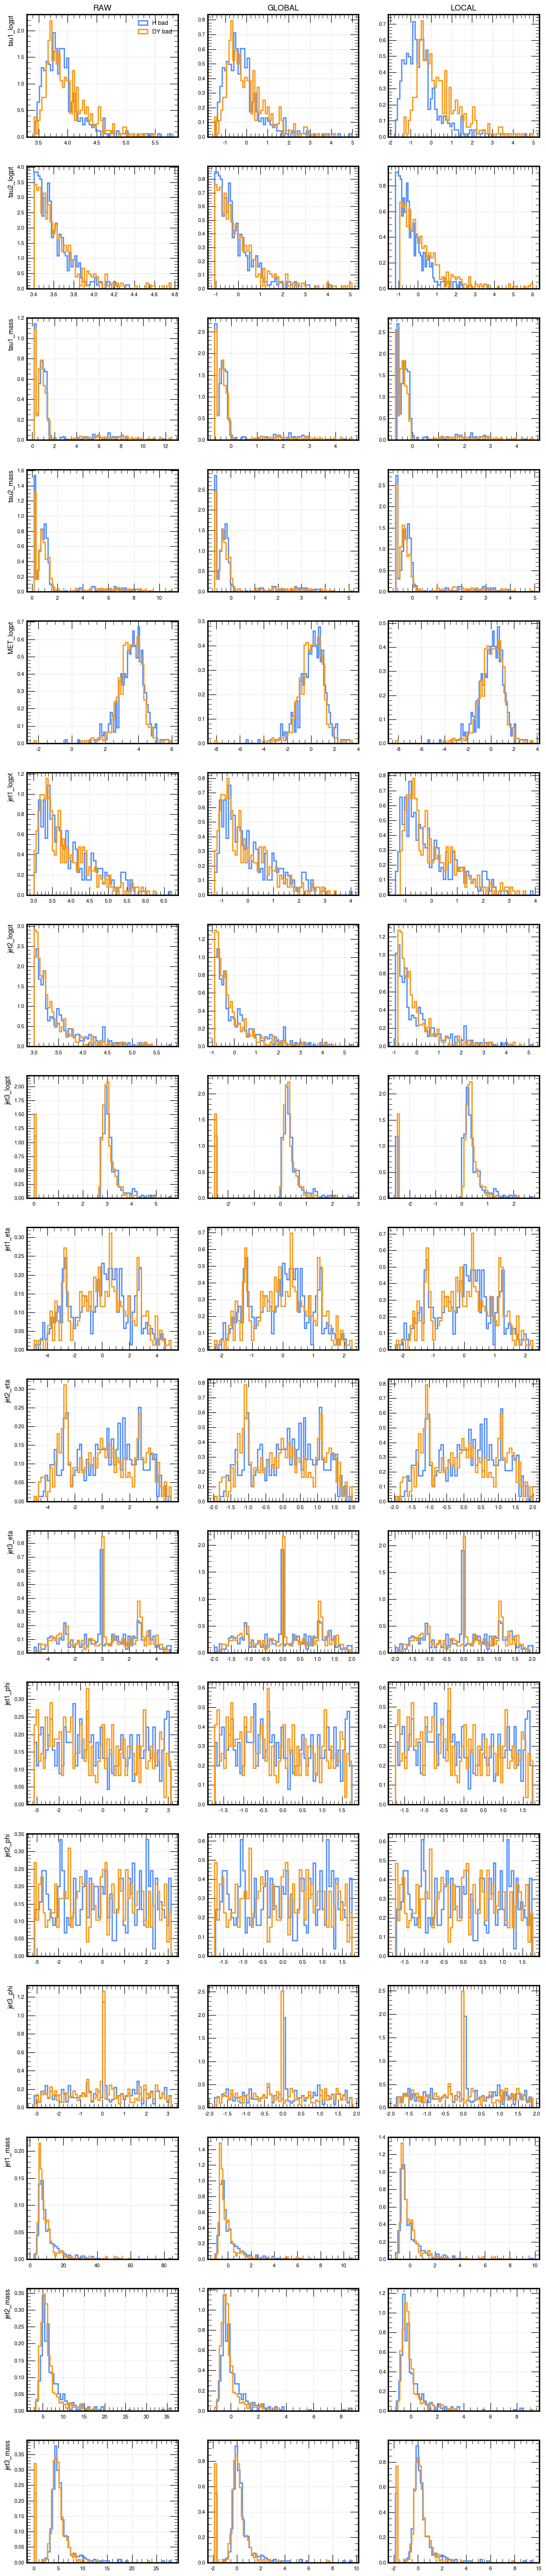

In [62]:
plot_bad_scaling_layout(
    df_h_raw=df_h_bad_raw_bal,
    df_dy_raw=df_dy_bad_raw_bal,
    df_h_global=df_h_bad_global_bal,
    df_dy_global=df_dy_bad_global_bal,
    df_h_local=df_h_bad_local_bal,
    df_dy_local=df_dy_bad_local_bal,
    features=features_to_check,
)

In [67]:
# TEST
# recupero gli scaler:
res_global_unbal = results_unbalanced_huber_pat100_ep5000_deep_jets["X_GLOBAL__Y_GLOBAL"]
res_local_unbal  = results_unbalanced_huber_pat100_ep5000_deep_jets["X_LOCAL__Y_LOCAL"]

scalers_global_unbal = res_global_unbal["scalers"]
scalers_local_unbal  = res_local_unbal["scalers"]

# balanced:
res_global_bal = results_balanced_huber_pat100_ep5000_deep_jets["X_GLOBAL__Y_GLOBAL"]
res_local_bal  = results_balanced_huber_pat100_ep5000_deep_jets["X_LOCAL__Y_LOCAL"]

scalers_global_bal = res_global_bal["scalers"]
scalers_local_bal  = res_local_bal["scalers"]

In [69]:
# seleziono i bad events raw 
mode = "X_GLOBAL__Y_GLOBAL"

m_pred_unbal = masses_unbalanced_huber_pat100_ep5000_deep_jets[mode]

mask_h_bad_unbal  = (df_test_all["class"].to_numpy() == 1) & (m_pred_unbal < 100)
mask_dy_bad_unbal = (df_test_all["class"].to_numpy() == 0) & (m_pred_unbal > 110)

df_h_bad_raw_unbal  = df_test_all[mask_h_bad_unbal].copy()
df_dy_bad_raw_unbal = df_test_all[mask_dy_bad_unbal].copy()

m_pred_bal = masses_balanced_huber_pat100_ep5000_deep_jets[mode]

mask_h_bad_bal  = (df_test_bal["class"].to_numpy() == 1) & (m_pred_bal < 100)
mask_dy_bad_bal = (df_test_bal["class"].to_numpy() == 0) & (m_pred_bal > 110)

df_h_bad_raw_bal  = df_test_bal[mask_h_bad_bal].copy()
df_dy_bad_raw_bal = df_test_bal[mask_dy_bad_bal].copy()

In [75]:
import fm.data as fm_data

df_h_bad_global_unbal = fm_data.transform_df(
    df=df_h_bad_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_global_unbal,
)

df_h_bad_local_unbal = fm_data.transform_df(
    df=df_h_bad_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_local_unbal,
)

df_dy_bad_global_unbal = fm_data.transform_df(
    df=df_dy_bad_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_global_unbal,
)

df_dy_bad_local_unbal = fm_data.transform_df(
    df=df_dy_bad_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_local_unbal,
)

In [82]:
def plot_feature_comparison_raw_global_local(
    df_h_raw,
    df_dy_raw,
    df_h_global,
    df_dy_global,
    df_h_local,
    df_dy_local,
    features,
    label_h="H",
    label_dy="DY",
    bins=60,
    density=True,
    figsize_per_row=2.7,
):

    n_features = len(features)

    fig, axes = plt.subplots(
        nrows=n_features,
        ncols=3,
        figsize=(12, figsize_per_row * n_features),
        squeeze=False,
    )

    col_titles = ["RAW", "GLOBAL", "LOCAL"]

    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title)

    for i, feat in enumerate(features):

        panels = [
            (df_h_raw, df_dy_raw),
            (df_h_global, df_dy_global),
            (df_h_local, df_dy_local),
        ]

        for j, (df_h, df_dy) in enumerate(panels):

            ax = axes[i, j]

            x_h  = df_h[feat].to_numpy()
            x_dy = df_dy[feat].to_numpy()

            x_h  = x_h[np.isfinite(x_h)]
            x_dy = x_dy[np.isfinite(x_dy)]

            ax.hist(
                x_h,
                bins=bins,
                density=density,
                histtype="step",
                linewidth=2,
                label=label_h,
            )

            ax.hist(
                x_dy,
                bins=bins,
                density=density,
                histtype="step",
                linewidth=2,
                label=label_dy,
            )

            if j == 0:
                ax.set_ylabel(feat)

            if i == 0 and j == 0:
                ax.legend()

    fig.tight_layout()
    plt.show()

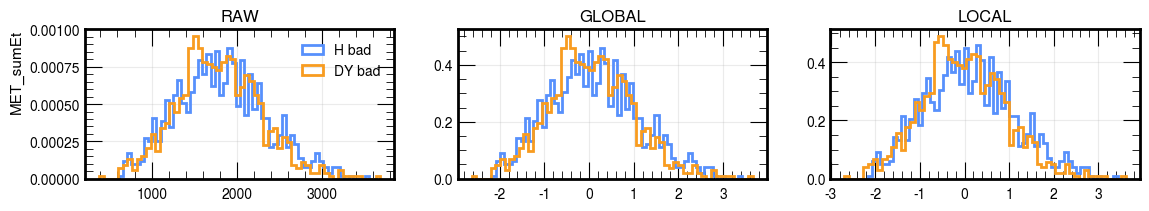

In [107]:
plot_feature_comparison_raw_global_local(
    df_h_raw=df_h_bad_raw_unbal,
    df_dy_raw=df_dy_bad_raw_unbal,
    df_h_global=df_h_bad_global_unbal,
    df_dy_global=df_dy_bad_global_unbal,
    df_h_local=df_h_bad_local_unbal,
    df_dy_local=df_dy_bad_local_unbal,
    features=features_to_check,
    label_h="H bad",
    label_dy="DY bad",
    bins=60,
)

## good events

In [79]:
mask_h_good_unbal = (df_test_all["class"] == 1) & (m_pred_unbal > 110)
mask_dy_good_unbal = (df_test_all["class"] == 0) & (m_pred_unbal < 100)

df_h_good_raw_unbal  = df_test_all[mask_h_good_unbal].copy()
df_dy_good_raw_unbal = df_test_all[mask_dy_good_unbal].copy()

print("H good:", len(df_h_good_raw_unbal))
print("DY good:", len(df_dy_good_raw_unbal))

H good: 8000
DY good: 809


In [80]:
df_h_good_global_unbal = fm_data.transform_df(
    df=df_h_good_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_global_unbal,
)

df_h_good_local_unbal = fm_data.transform_df(
    df=df_h_good_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_local_unbal,
)

df_dy_good_global_unbal = fm_data.transform_df(
    df=df_dy_good_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_global_unbal,
)

df_dy_good_local_unbal = fm_data.transform_df(
    df=df_dy_good_raw_unbal,
    train_cols=train_cols,
    y_cols=y_cols,
    scalers=scalers_local_unbal,
)

In [105]:
features_to_check = [    "MET_sumEt",
]

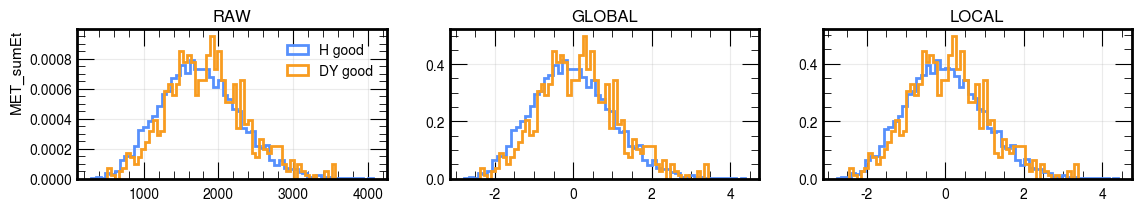

In [106]:
plot_feature_comparison_raw_global_local(
    df_h_raw=df_h_good_raw_unbal,
    df_dy_raw=df_dy_good_raw_unbal,
    df_h_global=df_h_good_global_unbal,
    df_dy_global=df_dy_good_global_unbal,
    df_h_local=df_h_good_local_unbal,
    df_dy_local=df_dy_good_local_unbal,
    features=features_to_check,
    label_h="H good",
    label_dy="DY good",
    bins=60,
)

# TEST
Provo a rifare lo scaling manualmente

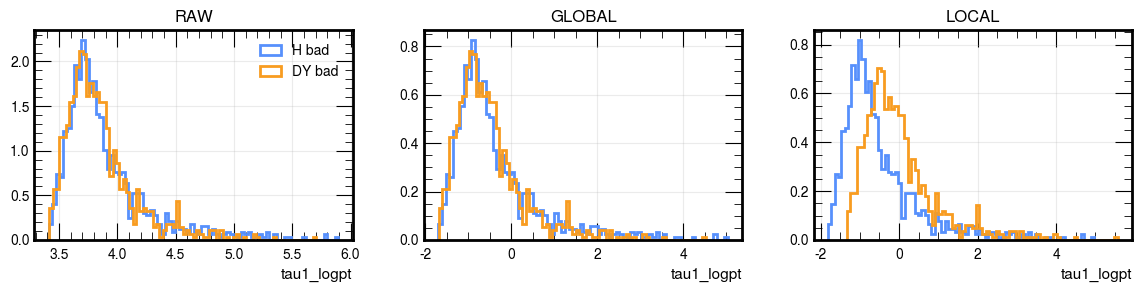

In [99]:
from sklearn.preprocessing import StandardScaler
feat = "tau1_logpt"

# =========================
# 1. training raw
# =========================
x_train_all = df_train_all[[feat]].to_numpy()

x_train_dy = df_train_all.loc[df_train_all["class"] == 0, [feat]].to_numpy()
x_train_h  = df_train_all.loc[df_train_all["class"] == 1, [feat]].to_numpy()

# =========================
# 2. fit degli scaler da zero
# =========================
scaler_global = StandardScaler()
scaler_global.fit(x_train_all)

scaler_local_dy = StandardScaler()
scaler_local_dy.fit(x_train_dy)

scaler_local_h = StandardScaler()
scaler_local_h.fit(x_train_h)

# =========================
# 3. bad events raw
# =========================
x_h_raw  = df_h_bad_raw_unbal[[feat]].to_numpy()
x_dy_raw = df_dy_bad_raw_unbal[[feat]].to_numpy()

# =========================
# 4. trasformazione
# =========================
x_h_global  = scaler_global.transform(x_h_raw).ravel()
x_dy_global = scaler_global.transform(x_dy_raw).ravel()

x_h_local  = scaler_local_h.transform(x_h_raw).ravel()
x_dy_local = scaler_local_dy.transform(x_dy_raw).ravel()

x_h_raw  = x_h_raw.ravel()
x_dy_raw = x_dy_raw.ravel()

# =========================
# 5. plot
# =========================
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), squeeze=False)
axes = axes[0]

panels = [
    (x_h_raw, x_dy_raw, "RAW"),
    (x_h_global, x_dy_global, "GLOBAL"),
    (x_h_local, x_dy_local, "LOCAL"),
]

for ax, (xh, xdy, title) in zip(axes, panels):
    ax.hist(xh, bins=80, density=True, histtype="step", linewidth=2, label="H bad")
    ax.hist(xdy, bins=80, density=True, histtype="step", linewidth=2, label="DY bad")
    ax.set_title(title)
    ax.set_xlabel(feat)

axes[0].legend()
plt.tight_layout()
plt.show()

## Recupero i test dataframes/creo i good/bad

In [119]:
jets_masses_split = {
    ("unbalanced", "dy"): masses_unbalanced_huber_pat100_ep5000_deep_jets_dy,
    ("unbalanced", "h"):  masses_unbalanced_huber_pat100_ep5000_deep_jets_h,
}

mode = "X_GLOBAL__Y_GLOBAL"   

m_dy = jets_masses_split[("unbalanced", "dy")][mode]
m_h  = jets_masses_split[("unbalanced", "h")][mode]

mask_dy = df_test_all["class"].to_numpy() == 0
mask_h  = df_test_all["class"].to_numpy() == 1

df_test_dy_jets = df_test_all.loc[mask_dy].copy()
df_test_h_jets  = df_test_all.loc[mask_h].copy()

print(len(m_dy), len(df_test_dy_jets))
print(len(m_h), len(df_test_h_jets))

1995 1995
9858 9858


In [121]:
print("DY mean:", np.mean(m_dy), "std:", np.std(m_dy))
print("H  mean:", np.mean(m_h),  "std:", np.std(m_h))

print("DY: 10 GeV / sigma =", 10 / np.std(m_dy))
print("H : 10 GeV / sigma =", 10 / np.std(m_h))

DY mean: 110.09744594444288 std: 26.234153906776896
H  mean: 121.5939278143106 std: 15.61650971789439
DY: 10 GeV / sigma = 0.38118248583640296
H : 10 GeV / sigma = 0.6403479510239963


In [122]:
# Per definire la finestra, meglio usare una sigma locale del picco, 
# stimata con un fit o almeno dentro una regione attorno alla massa nominale:

def estimate_local_sigma(m, mu_nominal, fit_window=20):
    m_local = m[np.abs(m - mu_nominal) < fit_window]
    return np.std(m_local)

sigma_dy = estimate_local_sigma(m_dy, 91.0, fit_window=20)
sigma_h  = estimate_local_sigma(m_h, 125.0, fit_window=20)

print("sigma DY local:", sigma_dy)
print("sigma H local :", sigma_h)

good_dy_mask = np.abs(m_dy - 91.0) < 2 * sigma_dy
bad_dy_mask  = ~good_dy_mask

good_h_mask = np.abs(m_h - 125.0) < 2 * sigma_h
bad_h_mask  = ~good_h_mask

print("good DY:", good_dy_mask.sum())
print("bad DY :", bad_dy_mask.sum())
print("good H :", good_h_mask.sum())
print("bad H  :", bad_h_mask.sum())

sigma DY local: 8.760847165299657
sigma H local : 8.233491374142087
good DY: 961
bad DY : 1034
good H : 7460
bad H  : 2398


In [123]:
# devo bilanciare i sample:
def balance_two_samples(df_a, df_b, random_state=0):
    n = min(len(df_a), len(df_b))
    df_a_bal = df_a.sample(n=n, random_state=random_state)
    df_b_bal = df_b.sample(n=n, random_state=random_state)
    return df_a_bal, df_b_bal

In [124]:
df_good_dy = df_test_dy_jets[good_dy_mask].copy()
df_bad_dy  = df_test_dy_jets[bad_dy_mask].copy()

df_good_h = df_test_h_jets[good_h_mask].copy()
df_bad_h  = df_test_h_jets[bad_h_mask].copy()

good_dy_bal, good_h_bal = balance_two_samples(df_good_dy, df_good_h)
bad_dy_bal, bad_h_bal   = balance_two_samples(df_bad_dy, df_bad_h)

good_dy_bal2, bad_h_bal = balance_two_samples(df_good_dy, df_bad_h)
bad_dy_bal2, good_h_bal2 = balance_two_samples(df_bad_dy, df_good_h)

In [125]:
good_dy_bal, good_h_bal = balance_two_samples(df_good_dy, df_good_h)

df_goodZ_goodH = pd.concat(
    [good_dy_bal, good_h_bal],
    ignore_index=True
)

bad_dy_bal, bad_h_bal = balance_two_samples(df_bad_dy, df_bad_h)

df_badZ_badH = pd.concat(
    [bad_dy_bal, bad_h_bal],
    ignore_index=True
)

good_dy_bal2, bad_h_bal = balance_two_samples(df_good_dy, df_bad_h)

df_goodZ_badH = pd.concat(
    [good_dy_bal2, bad_h_bal],
    ignore_index=True
)

bad_dy_bal2, good_h_bal2 = balance_two_samples(df_bad_dy, df_good_h)

df_badZ_goodH = pd.concat(
    [bad_dy_bal2, good_h_bal2],
    ignore_index=True
)

In [126]:
OUT_BDT = "results/bdt_datasets"
os.makedirs(OUT_BDT, exist_ok=True)

df_goodZ_goodH.to_pickle(
    os.path.join(OUT_BDT, "df_goodZ_goodH.pkl")
)

df_badZ_badH.to_pickle(
    os.path.join(OUT_BDT, "df_badZ_badH.pkl")
)

df_goodZ_badH.to_pickle(
    os.path.join(OUT_BDT, "df_goodZ_badH.pkl")
)

df_badZ_goodH.to_pickle(
    os.path.join(OUT_BDT, "df_badZ_goodH.pkl")
)

In [136]:
# check, es.:
print(len(df_badZ_goodH))
print(df_badZ_goodH["class"].value_counts())

2068
class
0    1034
1    1034
Name: count, dtype: int64


In [138]:
# salvo gli split per poterli utilizzare nel BDT
OUT_SPLITS = "../results/shared_splits"
os.makedirs(OUT_SPLITS, exist_ok=True)

# save FM splits
df_train_bal.to_pickle(
    os.path.join(
        OUT_SPLITS,
        "df_train_bal_fm.pkl",
    )
)

df_val_bal.to_pickle(
    os.path.join(
        OUT_SPLITS,
        "df_val_bal_fm.pkl",
    )
)

df_test_bal.to_pickle(
    os.path.join(
        OUT_SPLITS,
        "df_test_bal_fm.pkl",
    )
)

print("Saved:")
print(os.path.join(OUT_SPLITS, "df_train_bal_fm.pkl"))
print(os.path.join(OUT_SPLITS, "df_val_bal_fm.pkl"))
print(os.path.join(OUT_SPLITS, "df_test_bal_fm.pkl"))

print()
print("Shapes:")
print("train:", df_train_bal.shape)
print("val  :", df_val_bal.shape)
print("test :", df_test_bal.shape)

Saved:
../results/shared_splits/df_train_bal_fm.pkl
../results/shared_splits/df_val_bal_fm.pkl
../results/shared_splits/df_test_bal_fm.pkl

Shapes:
train: (32244, 76)
val  : (4031, 76)
test : (4031, 76)


## Balanced vs Unbalanced CHECK

In [141]:
OUT_MASSES = "../results/masses"

MODES = [
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
]

jets_masses_split = {}

for dataset_tag in ["unbalanced", "balanced"]:
    for proc in ["dy", "h"]:

        fname = f"masses_{dataset_tag}_huber_pat100_ep5000_deep_jets_{proc}.npz"
        path = os.path.join(OUT_MASSES, fname)

        data = np.load(path)

        jets_masses_split[(dataset_tag, proc)] = {
            k: data[k] for k in data.files
        }

        print("loaded ->", fname)

loaded -> masses_unbalanced_huber_pat100_ep5000_deep_jets_dy.npz
loaded -> masses_unbalanced_huber_pat100_ep5000_deep_jets_h.npz
loaded -> masses_balanced_huber_pat100_ep5000_deep_jets_dy.npz
loaded -> masses_balanced_huber_pat100_ep5000_deep_jets_h.npz


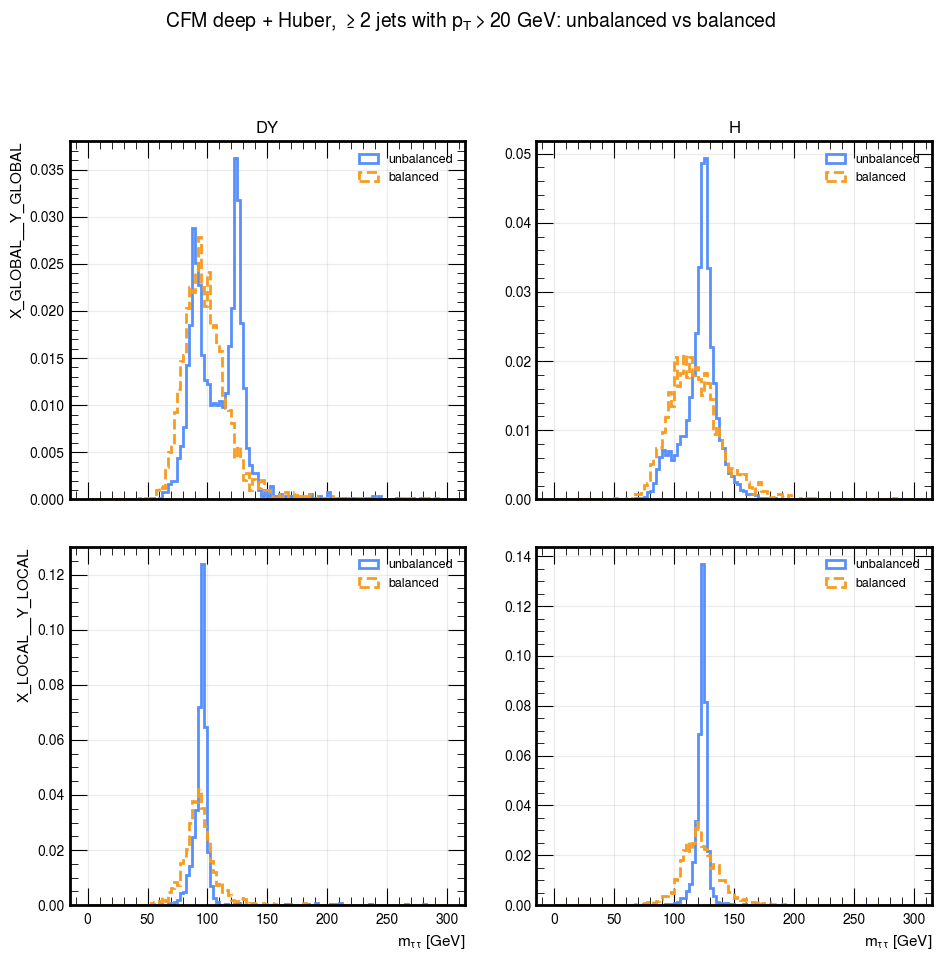

In [142]:
PROCS = ["dy", "h"]

fig, axes = plt.subplots(
    nrows=len(MODES),
    ncols=len(PROCS),
    figsize=(10, 10),
    sharex=True,
    sharey=False,
)

for i, mode in enumerate(MODES):
    for j, proc in enumerate(PROCS):

        ax = axes[i, j]

        m_unbal = jets_masses_split[("unbalanced", proc)][mode]
        m_bal   = jets_masses_split[("balanced", proc)][mode]

        ax.hist(
            m_unbal,
            bins=120,
            range=(0, 300),
            density=True,
            histtype="step",
            linewidth=2,
            label="unbalanced",
        )

        ax.hist(
            m_bal,
            bins=120,
            range=(0, 300),
            density=True,
            histtype="step",
            linewidth=2,
            linestyle="--",
            label="balanced",
        )

        if i == 0:
            ax.set_title(proc.upper())

        if j == 0:
            ax.set_ylabel(mode)

        if i == len(MODES) - 1:
            ax.set_xlabel(r"$m_{\tau\tau}$ [GeV]")

        ax.legend(fontsize=9)

fig.suptitle(
    r"CFM deep + Huber, $\geq 2$ jets with $p_T>20$ GeV: unbalanced vs balanced",
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [143]:
results_SB_jets_bal_vs_unbal = []

for dataset_tag in ["unbalanced", "balanced"]:

    for mode in MODES:

        h  = jets_masses_split[(dataset_tag, "h")][mode]
        dy = jets_masses_split[(dataset_tag, "dy")][mode]

        mu, sigma, low, high = analysis.fit_signal_window(h)

        S, B, SB, SsqrtB = analysis.compute_SB(
            h,
            dy,
            window=(low, high),
        )

        results_SB_jets_bal_vs_unbal.append({
            "dataset": dataset_tag,
            "selection": "jets_pt20",
            "mode": mode,
            "mu": mu,
            "sigma": sigma,
            "low": low,
            "high": high,
            "S": S,
            "B": B,
            "S/B": SB,
            "S/sqrtB": SsqrtB,
        })

        print(
            dataset_tag,
            mode,
            f"mu={mu:.2f}",
            f"sigma={sigma:.2f}",
            f"window=[{low:.2f},{high:.2f}]",
            f"S={S}",
            f"B={B}",
            f"S/B={SB:.3f}",
            f"S/sqrtB={SsqrtB:.3f}",
        )

results_SB_jets_bal_vs_unbal_df = pd.DataFrame(results_SB_jets_bal_vs_unbal)
results_SB_jets_bal_vs_unbal_df

unbalanced X_GLOBAL__Y_GLOBAL mu=121.59 sigma=15.62 window=[90.36,152.83] S=9200 B=1487 S/B=6.187 S/sqrtB=238.579
unbalanced X_LOCAL__Y_LOCAL mu=123.04 sigma=6.74 window=[109.55,136.52] S=9506 B=10 S/B=950.600 S/sqrtB=3006.061
balanced X_GLOBAL__Y_GLOBAL mu=117.27 sigma=22.16 window=[72.96,161.59] S=1954 B=1849 S/B=1.057 S/sqrtB=45.442
balanced X_LOCAL__Y_LOCAL mu=122.21 sigma=17.88 window=[86.44,157.98] S=1935 B=1448 S/B=1.336 S/sqrtB=50.851


,dataset,selection,mode,mu,sigma,low,high,S,B,S/B,S/sqrtB
0,unbalanced,jets_pt20,X_GLOBAL__Y_GLOBAL,121.593928,15.616510,90.360908,152.826947,9200,1487,6.186954,238.579071
1,unbalanced,jets_pt20,X_LOCAL__Y_LOCAL,123.037713,6.741823,109.554067,136.521359,9506,10,950.600000,3006.061144
2,balanced,jets_pt20,X_GLOBAL__Y_GLOBAL,117.271818,22.157869,72.956081,161.587555,1954,1849,1.056787,45.441860
3,balanced,jets_pt20,X_LOCAL__Y_LOCAL,122.214374,17.884853,86.444669,157.984080,1935,1448,1.336326,50.850671


In [144]:
results_SB_jets_bal_vs_unbal_df.pivot(
    index="mode",
    columns="dataset",
    values=["S/B", "S/sqrtB"]
)

S/B                S/sqrtB             
dataset             balanced  unbalanced   balanced   unbalanced
mode                                                            
X_GLOBAL__Y_GLOBAL  1.056787    6.186954  45.441860   238.579071
X_LOCAL__Y_LOCAL    1.336326  950.600000  50.850671  3006.061144

In [145]:
# check :
for dataset_tag in ["balanced", "unbalanced"]:

    h = jets_masses_split[(dataset_tag,"h")]["X_LOCAL__Y_LOCAL"]
    dy = jets_masses_split[(dataset_tag,"dy")]["X_LOCAL__Y_LOCAL"]

    mu, sigma, low, high = analysis.fit_signal_window(h)

    S, B, SB, SsqrtB = analysis.compute_SB(
        h,
        dy,
        (low, high),
    )

    print()
    print(dataset_tag)

    print(
        f"window=[{low:.1f},{high:.1f}]"
    )

    print(
        f"S={S}"
    )

    print(
        f"B={B}"
    )

    print(
        f"S/B={SB}"
    )


balanced
window=[86.4,158.0]
S=1935
B=1448
S/B=1.3363259668508287

unbalanced
window=[109.6,136.5]
S=9506
B=10
S/B=950.6


In [146]:
WINDOW = (110,130)

rows=[]

for dataset_tag in ["balanced","unbalanced"]:

    h = jets_masses_split[(dataset_tag,"h")]["X_LOCAL__Y_LOCAL"]
    dy = jets_masses_split[(dataset_tag,"dy")]["X_LOCAL__Y_LOCAL"]

    S,B,SB,SsqrtB = analysis.compute_SB(
        h,
        dy,
        WINDOW,
    )

    rows.append({
        "dataset": dataset_tag,
        "S": S,
        "B": B,
        "S/B": SB,
        "S/sqrtB": SsqrtB,
    })

pd.DataFrame(rows)

,dataset,S,B,S/B,S/sqrtB
0,balanced,1033,150,6.886667,84.344097
1,unbalanced,9211,9,1023.444444,3070.333333
